In [1]:
from pathlib import Path

from src.baseline_config import build_training_config
from src.phase2.config import PHASE2_CONFIDENCE_ONLY_FRAMES_DIR, PHASE2_FRAMES_DIR
from src.phase3.config import PHASE3_RUNS
from src.phase3.experiment import (
    print_phase3_dataset_summary,
    print_phase3_summary,
    print_phase3_test_summary,
    show_phase3_plots,
    train_phase3_dataset,
)

TRAINING_CONFIG = build_training_config(architecture='efficientnet_b0')
PHASE3_RESULTS_ROOT = Path("phase3")

PHASE3_EXPERIMENTS = [
    {
        "descriptor": "conf060_dedup_p75_25",
        "train_csv": Path("phase3test") / "phase3_conf060_dedup_p75_25.csv",
        "images_dir": PHASE2_CONFIDENCE_ONLY_FRAMES_DIR,
    },
    {
        "descriptor": "kinf_dedup_p75_25",
        "train_csv": Path("phase3test") / "phase3_kinf_dedup_p75_25.csv",
        "images_dir": PHASE2_FRAMES_DIR,
    },
]

FORCE_TRAIN = False


In [2]:
for experiment in PHASE3_EXPERIMENTS:
    print("=" * 100)
    print(experiment["descriptor"])
    print_phase3_dataset_summary(experiment["train_csv"])


conf060_dedup_p75_25
Rows: 10058
histology
Adenoma                     5591
Sessile_serrated_adenoma    2613
Hyperplastic                1339
Adenocarcinoma               515
kinf_dedup_p75_25
Rows: 5886
histology
Adenoma                     2333
Sessile_serrated_adenoma    1782
Hyperplastic                1100
Adenocarcinoma               671


In [3]:
for experiment in PHASE3_EXPERIMENTS:
    print("=" * 100)
    print(f"Training {experiment['descriptor']}")
    train_phase3_dataset(
        train_csv=experiment["train_csv"],
        descriptor=experiment["descriptor"],
        force_train=FORCE_TRAIN,
        training_config=TRAINING_CONFIG,
        runs=PHASE3_RUNS,
        results_root=PHASE3_RESULTS_ROOT,
        train_images_dir=experiment["images_dir"],
    )


Training conf060_dedup_p75_25
Loading model located at: C:\Users\luis\Documents\TFG - Data-Centric AI\results\EfficientNet\phase3\conf060_dedup_p75_25\seed_1\best_baseline_model.pth
Loading model located at: C:\Users\luis\Documents\TFG - Data-Centric AI\results\EfficientNet\phase3\conf060_dedup_p75_25\seed_2\best_baseline_model.pth
Loading model located at: C:\Users\luis\Documents\TFG - Data-Centric AI\results\EfficientNet\phase3\conf060_dedup_p75_25\seed_3\best_baseline_model.pth
Loading model located at: C:\Users\luis\Documents\TFG - Data-Centric AI\results\EfficientNet\phase3\conf060_dedup_p75_25\seed_4\best_baseline_model.pth
Training kinf_dedup_p75_25
Loading model located at: C:\Users\luis\Documents\TFG - Data-Centric AI\results\EfficientNet\phase3\kinf_dedup_p75_25\seed_1\best_baseline_model.pth
Loading model located at: C:\Users\luis\Documents\TFG - Data-Centric AI\results\EfficientNet\phase3\kinf_dedup_p75_25\seed_2\best_baseline_model.pth
Loss weights: {'Adenoma': 0.6357, 'Se

Training Progress:  56%|█████▌    | 56/100 [29:38<23:17, 31.76s/epoch, Stage=full_network, Train Loss=0.1896, Val Loss=0.4006, Val Macro F1=0.5512, Selection Score=-0.5512, Best Epoch=41, LR=1.0e-07/3.9e-07]       


Early stopping triggered after 16 epochs without improving macro_f1.
Optimization sequence completed with seed 456. Selected checkpoint macro-F1: 0.5628 with validation loss 0.3999 and validation score -0.5628 at epoch 41.
Artifacts successfully written to 'C:\Users\luis\Documents\TFG - Data-Centric AI\results\EfficientNet\phase3\kinf_dedup_p75_25\seed_3'.
Loss weights: {'Adenoma': 0.6357, 'Sessile_serrated_adenoma': 0.7676, 'Hyperplastic': 1.076, 'Adenocarcinoma': 1.5208}
Initiating training phase. Saving results to: C:\Users\luis\Documents\TFG - Data-Centric AI\results\EfficientNet\phase3\kinf_dedup_p75_25\seed_4


Training Progress:  64%|██████▍   | 64/100 [33:50<19:02, 31.73s/epoch, Stage=full_network, Train Loss=0.2087, Val Loss=0.3919, Val Macro F1=0.5466, Selection Score=-0.5466, Best Epoch=49, LR=1.0e-07/1.0e-07]       


Early stopping triggered after 16 epochs without improving macro_f1.
Optimization sequence completed with seed 789. Selected checkpoint macro-F1: 0.5625 with validation loss 0.3984 and validation score -0.5625 at epoch 49.
Artifacts successfully written to 'C:\Users\luis\Documents\TFG - Data-Centric AI\results\EfficientNet\phase3\kinf_dedup_p75_25\seed_4'.


Plots conf060_dedup_p75_25


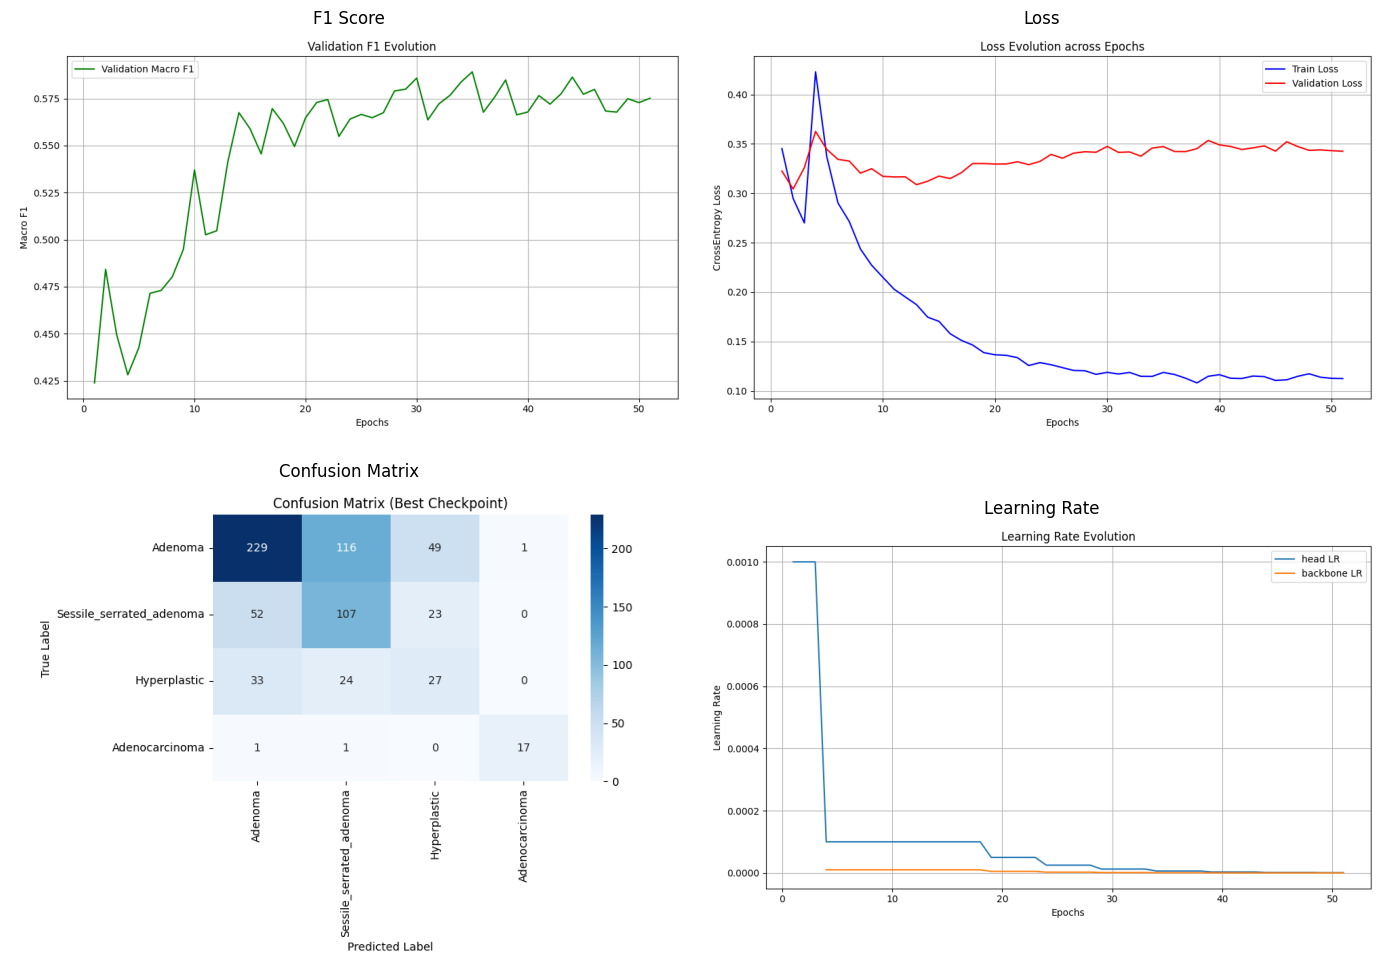

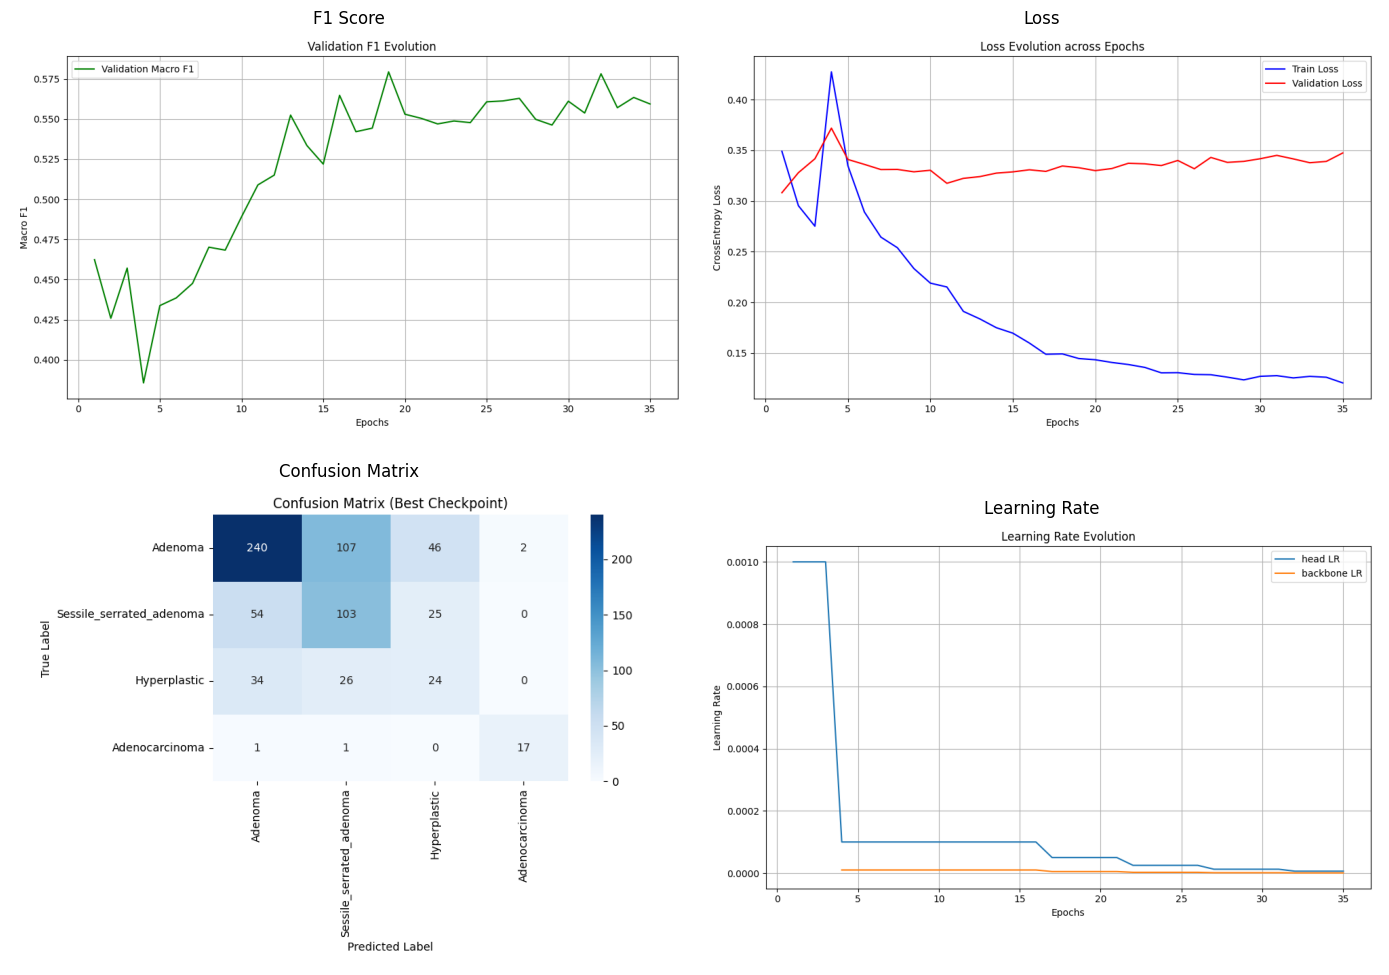

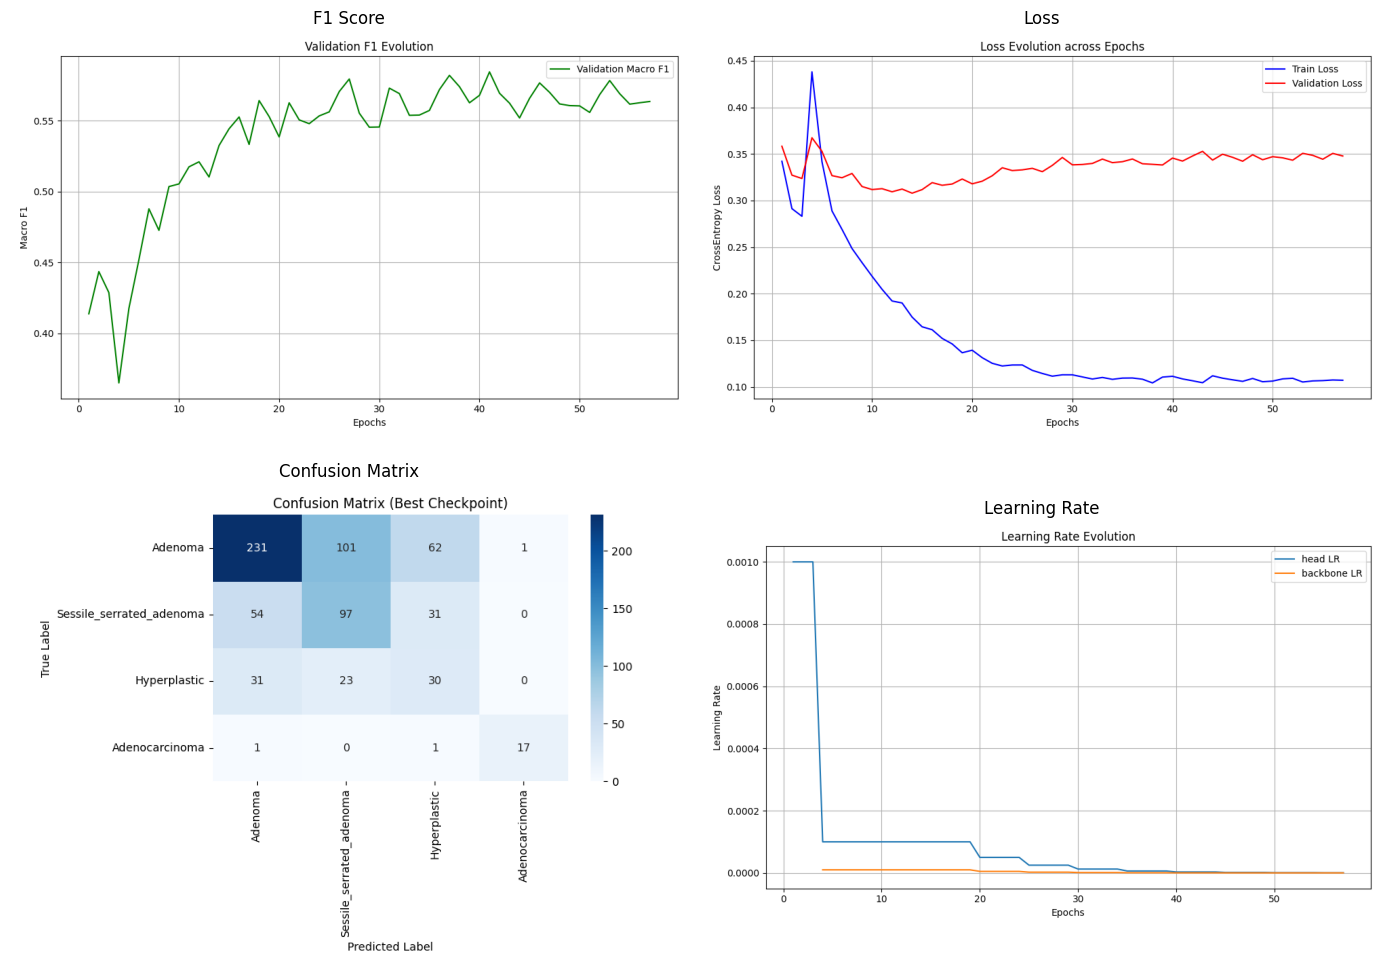

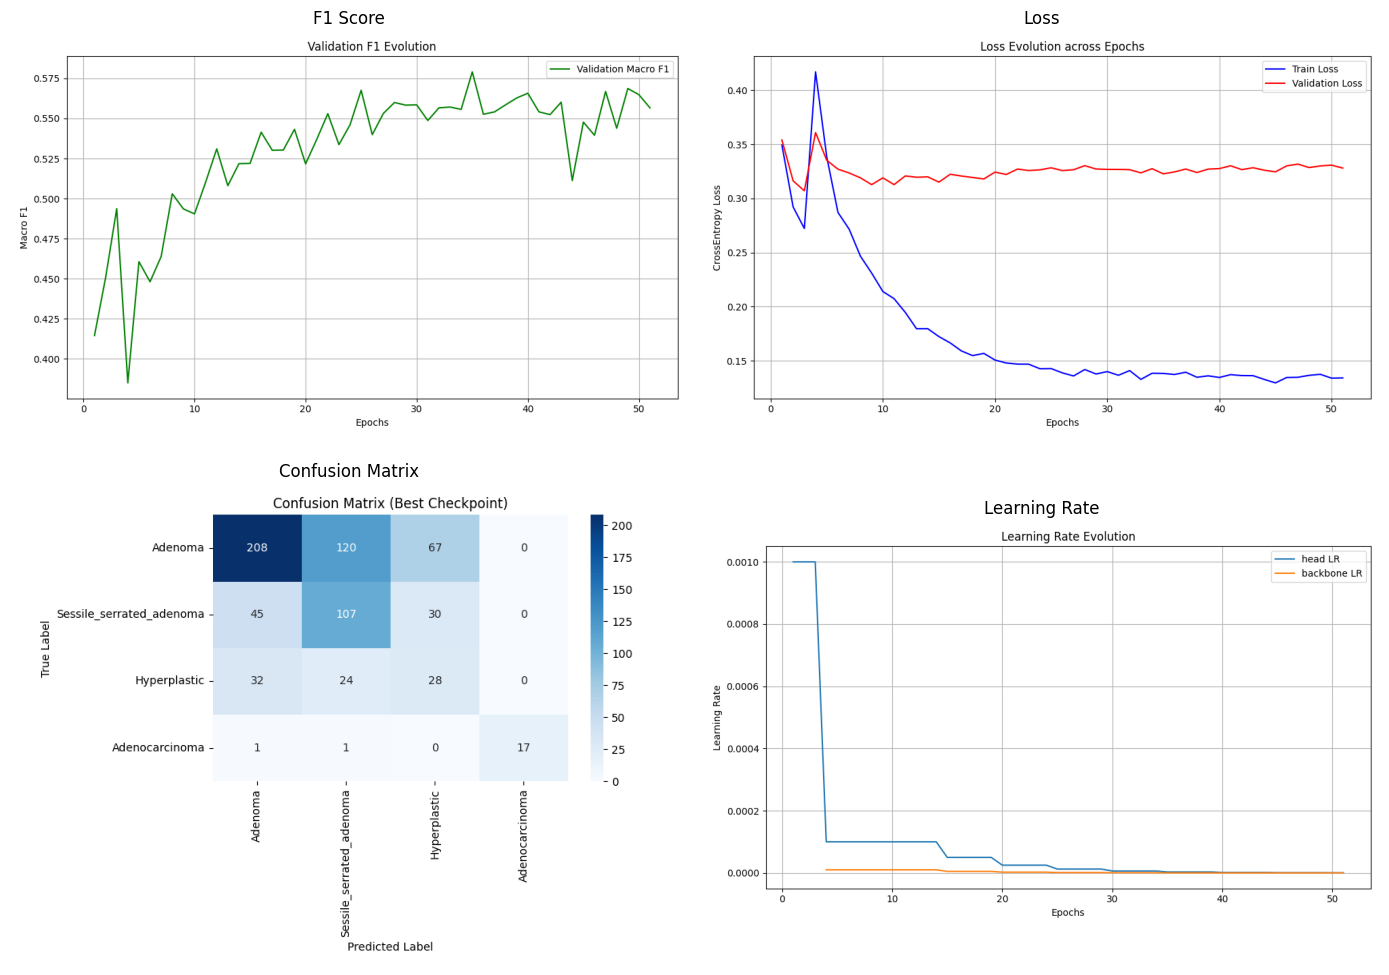

Plots kinf_dedup_p75_25


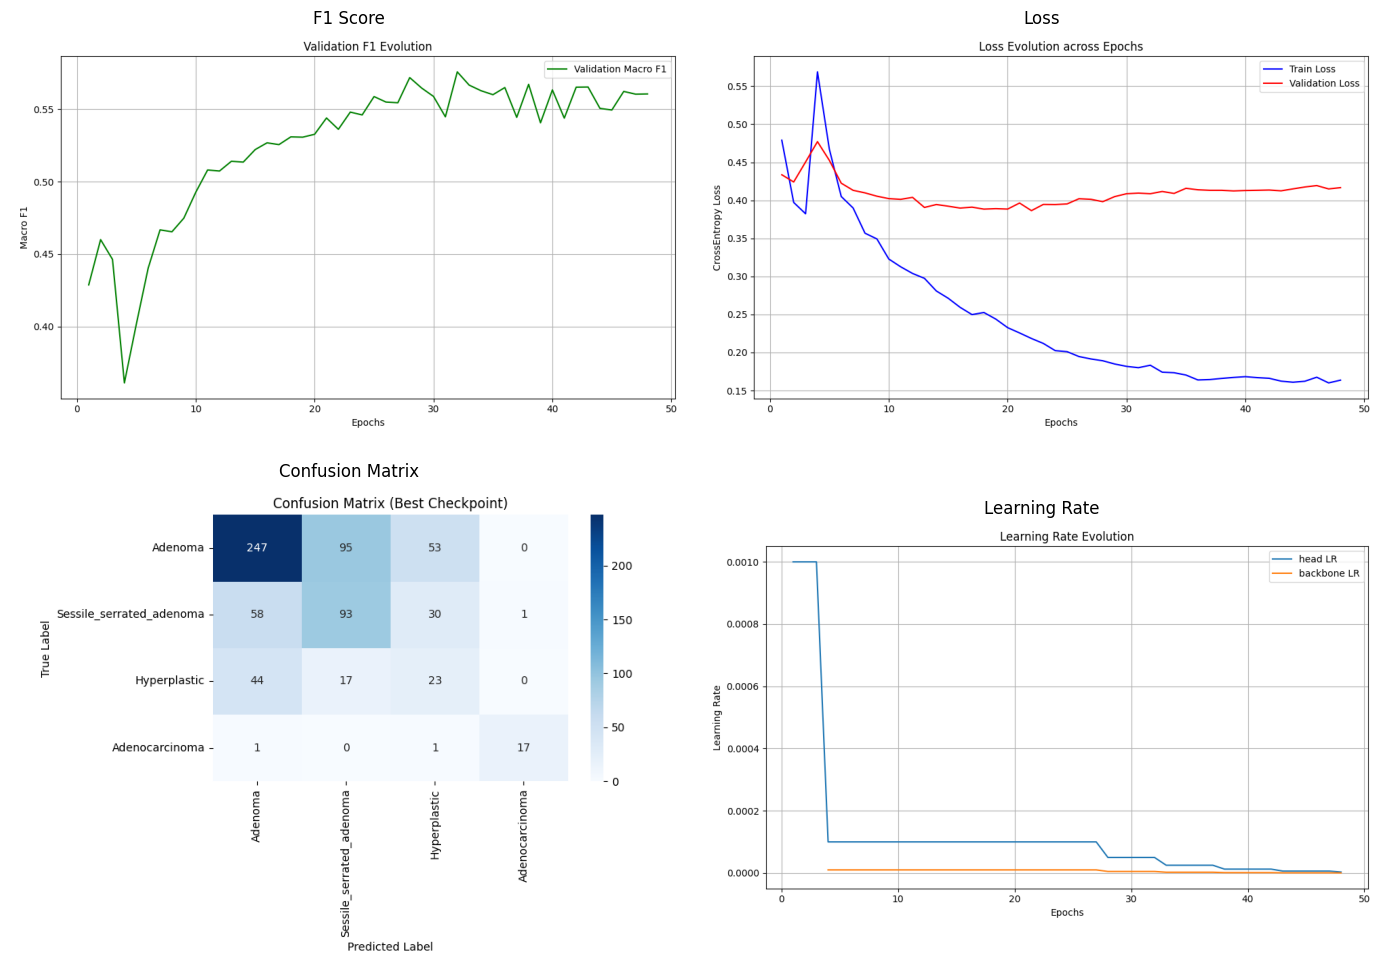

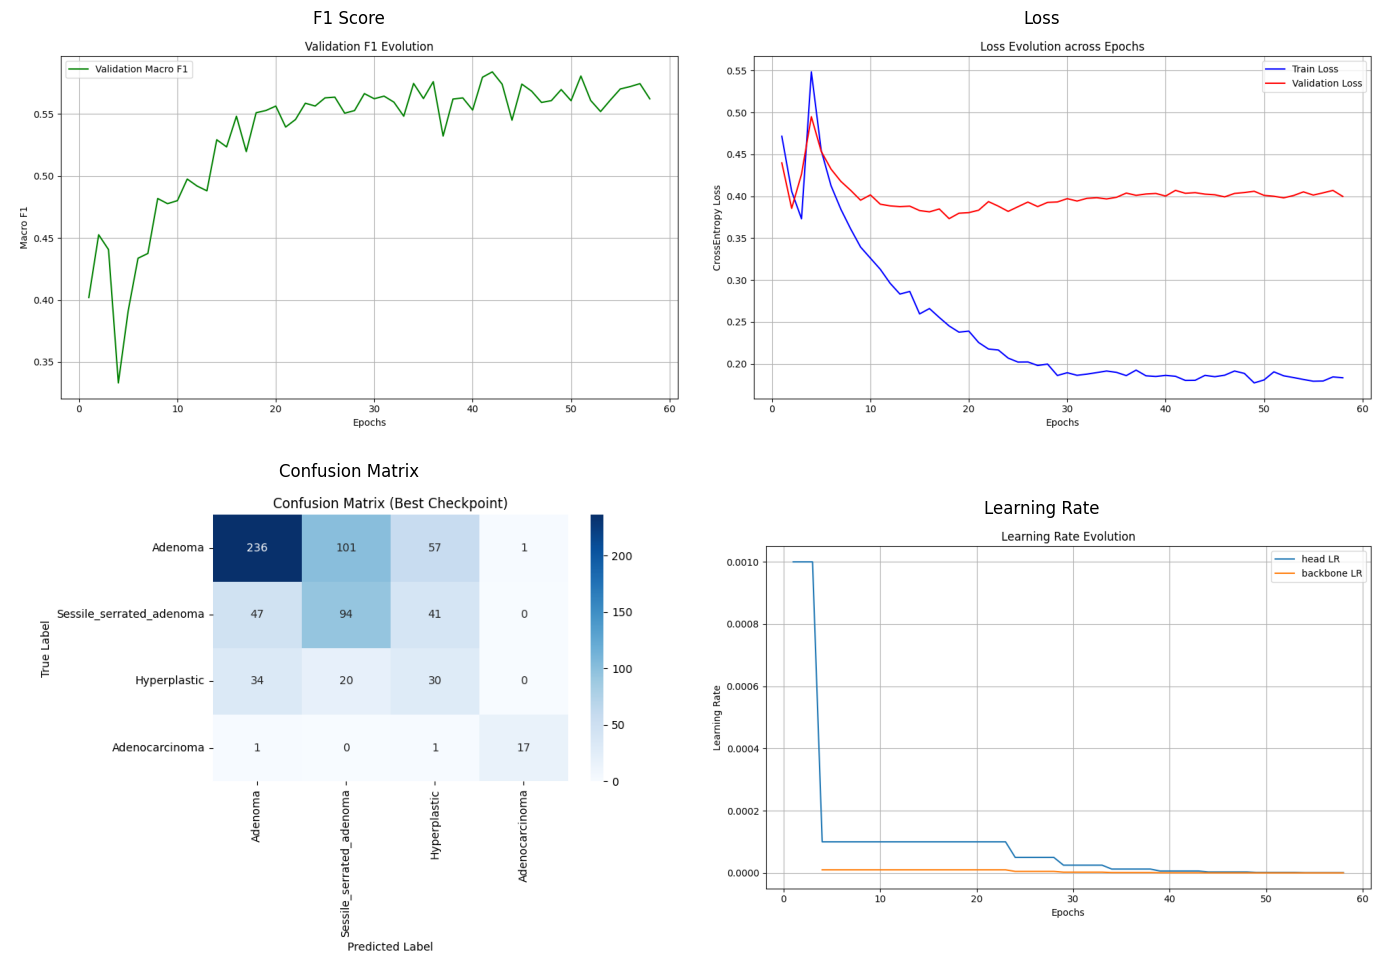

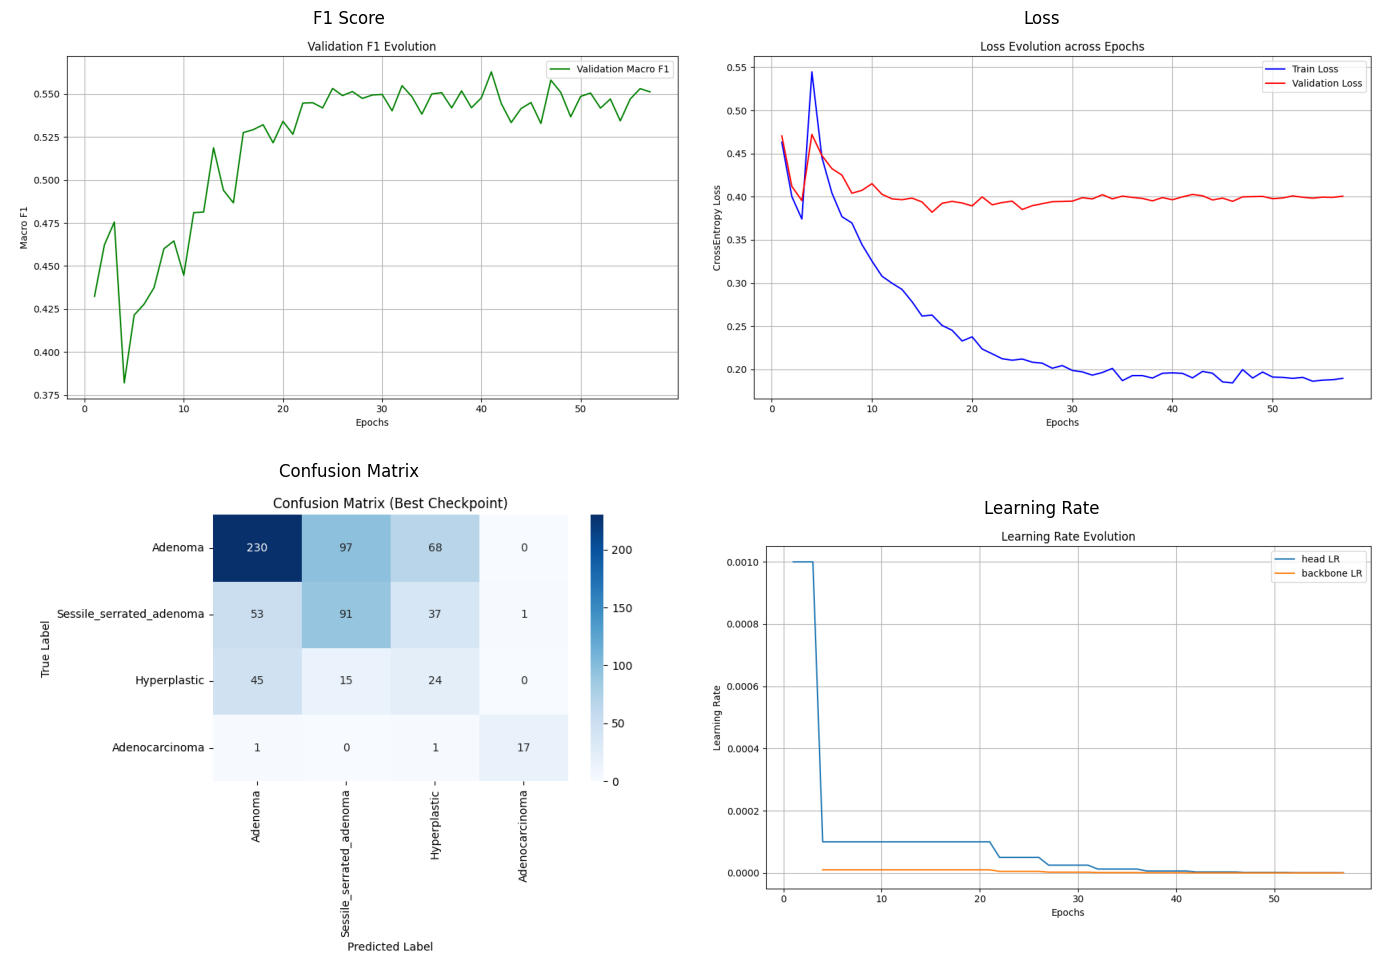

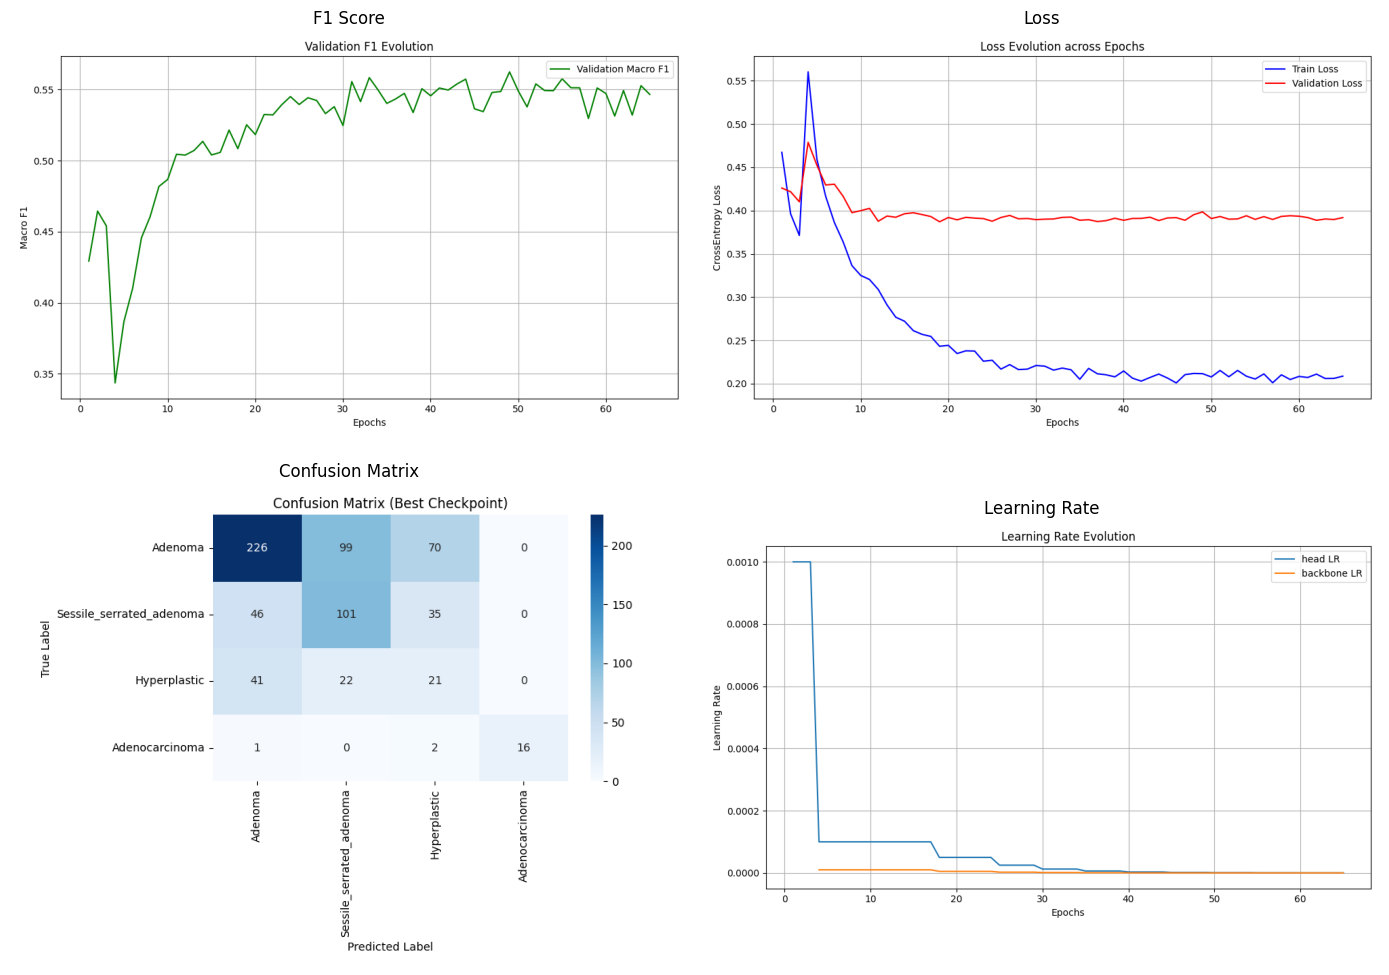

In [4]:
for experiment in PHASE3_EXPERIMENTS:
    print("=" * 100)
    print(f"Plots {experiment['descriptor']}")
    show_phase3_plots(
        train_csv=experiment["train_csv"],
        descriptor=experiment["descriptor"],
        training_config=TRAINING_CONFIG,
        runs=PHASE3_RUNS,
        results_root=PHASE3_RESULTS_ROOT,
    )


In [5]:
for experiment in PHASE3_EXPERIMENTS:
    print("=" * 100)
    print(f"Validation summary {experiment['descriptor']}")
    display(print_phase3_summary(
        train_csv=experiment["train_csv"],
        descriptor=experiment["descriptor"],
        training_config=TRAINING_CONFIG,
        runs=PHASE3_RUNS,
        results_root=PHASE3_RESULTS_ROOT,
    ))


Validation summary conf060_dedup_p75_25


,scope,accuracy,mcc,macro_f1,precision,recall
0,general,0.5511 +/- 0.0154,0.2804 +/- 0.0105,0.5830 +/- 0.0048,0.5886 +/- 0.0076,0.5906 +/- 0.0045
1,Adenoma,0.6283 +/- 0.0130,0.2748 +/- 0.0163,0.6419 +/- 0.0221,0.7281 +/- 0.0012,0.5747 +/- 0.0343
2,Sessile_serrated_adenoma,0.6846 +/- 0.0068,0.2742 +/- 0.0051,0.4909 +/- 0.0069,0.4324 +/- 0.0060,0.5687 +/- 0.0260
3,Hyperplastic,0.7937 +/- 0.0177,0.1650 +/- 0.0180,0.2799 +/- 0.0140,0.2478 +/- 0.0204,0.3244 +/- 0.0298
4,Adenocarcinoma,0.9956 +/- 0.0012,0.9176 +/- 0.0216,0.9193 +/- 0.0203,0.9459 +/- 0.0430,0.8947 +/- 0.0000


Validation summary kinf_dedup_p75_25


,scope,accuracy,mcc,macro_f1,precision,recall
0,general,0.5452 +/- 0.0133,0.2627 +/- 0.0183,0.5713 +/- 0.0105,0.5806 +/- 0.0086,0.5720 +/- 0.0156
1,Adenoma,0.6276 +/- 0.0143,0.2649 +/- 0.0308,0.6495 +/- 0.0151,0.7167 +/- 0.0190,0.5943 +/- 0.0231
2,Sessile_serrated_adenoma,0.7004 +/- 0.0053,0.2743 +/- 0.0150,0.4817 +/- 0.0127,0.4485 +/- 0.0081,0.5206 +/- 0.0239
3,Hyperplastic,0.7669 +/- 0.0170,0.1075 +/- 0.0431,0.2362 +/- 0.0350,0.1990 +/- 0.0306,0.2917 +/- 0.0461
4,Adenocarcinoma,0.9956 +/- 0.0000,0.9167 +/- 0.0007,0.9178 +/- 0.0023,0.9583 +/- 0.0278,0.8816 +/- 0.0263


In [ ]:
for experiment in PHASE3_EXPERIMENTS:
    print("=" * 100)
    print(f"Test summary {experiment['descriptor']}")
    display(print_phase3_test_summary(
        train_csv=experiment["train_csv"],
        descriptor=experiment["descriptor"],
        training_config=TRAINING_CONFIG,
        runs=PHASE3_RUNS,
        results_root=PHASE3_RESULTS_ROOT,
    ))


Test summary conf060_dedup_p75_25


,scope,accuracy,mcc,macro_f1,precision,recall
0,general,0.3878 +/- 0.0247,0.2506 +/- 0.0248,0.3360 +/- 0.0207,0.4438 +/- 0.0024,0.4595 +/- 0.0431
1,Adenoma,0.6464 +/- 0.0163,0.2029 +/- 0.0287,0.4585 +/- 0.0236,0.4175 +/- 0.0178,0.5104 +/- 0.0450
2,Sessile_serrated_adenoma,0.6590 +/- 0.0170,0.0928 +/- 0.0347,0.0577 +/- 0.0114,0.0301 +/- 0.0060,0.7083 +/- 0.1232
3,Hyperplastic,0.6682 +/- 0.0033,0.0504 +/- 0.0184,0.1679 +/- 0.0449,0.3871 +/- 0.0152,0.1087 +/- 0.0363
4,Adenocarcinoma,0.8021 +/- 0.0189,0.5885 +/- 0.0355,0.6597 +/- 0.0508,0.9404 +/- 0.0171,0.5108 +/- 0.0620


Test summary kinf_dedup_p75_25


,scope,accuracy,mcc,macro_f1,precision,recall
0,general,0.4175 +/- 0.0140,0.2749 +/- 0.0170,0.3580 +/- 0.0151,0.4654 +/- 0.0089,0.4834 +/- 0.0127
1,Adenoma,0.6458 +/- 0.0207,0.2276 +/- 0.0169,0.4827 +/- 0.0066,0.4244 +/- 0.0207,0.5623 +/- 0.0355
2,Sessile_serrated_adenoma,0.7028 +/- 0.0097,0.1075 +/- 0.0081,0.0653 +/- 0.0033,0.0343 +/- 0.0018,0.7083 +/- 0.0278
3,Hyperplastic,0.6806 +/- 0.0046,0.1054 +/- 0.0135,0.2131 +/- 0.0336,0.4663 +/- 0.0223,0.1393 +/- 0.0284
4,Adenocarcinoma,0.8060 +/- 0.0122,0.5958 +/- 0.0242,0.6708 +/- 0.0296,0.9367 +/- 0.0216,0.5237 +/- 0.0404


: 